# Monte Carlo Simulation V3 — Final
Group stage + Proper seeding + Poisson scoring + Confederation adjustment + Host nation boost

# Monte Carlo Simulation V3 — Final
Group stage + Proper seeding + Poisson scoring + Confederation adjustment + Host nation boost


In [14]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE = r'C:\Project\FIFA_World_Cup_2026'

with open(os.path.join(BASE, 'Model_Training', 'xgb_model_v3.pkl'), 'rb') as f:
    xgb_model = pickle.load(f)

with open(os.path.join(BASE, 'Model_Training', 'label_encoder_v3.pkl'), 'rb') as f:
    le = pickle.load(f)

features_df = pd.read_csv(os.path.join(BASE, 'Feature_Engineering', 'features_v3.csv'))
elo = pd.read_csv(os.path.join(BASE, 'Cleaned_Data', 'elo_cleaned.csv'))
player_strength = pd.read_csv(os.path.join(BASE, 'Cleaned_Data', 'player_strength.csv'))
star_elo = pd.read_csv(os.path.join(BASE, 'Cleaned_Data', 'star_player_elo.csv'))
squad_age = pd.read_csv(os.path.join(BASE, 'Cleaned_Data', 'squad_age.csv'))
elo_conf = pd.read_csv(os.path.join(BASE, 'Cleaned_Data', 'confederation_strength.csv'))

print("All loaded!")

All loaded!


## Official 2026 World Cup Groups

In [16]:
# Official 2026 FIFA World Cup Groups
wc_groups = {
    'A': ['Mexico', 'South Korea', 'South Africa', 'Czech Republic'],
    'B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
    'E': ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'I': ['France', 'Senegal', 'Iraq', 'Norway'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['Portugal', 'DR Congo', 'Colombia', 'Uzbekistan'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama']
}


# All 48 teams
wc_teams = [team for group in wc_groups.values() for team in group]
print(f"Total teams: {len(wc_teams)}")
print("\nGroups:")
for g, teams in wc_groups.items():
    print(f"Group {g}: {teams}")

Total teams: 48
Group A: ['Mexico', 'South Korea', 'South Africa', 'Czech Republic']
Group B: ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland']
Group C: ['Brazil', 'Morocco', 'Haiti', 'Scotland']
Group D: ['United States', 'Paraguay', 'Australia', 'Turkey']
Group E: ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador']
Group F: ['Netherlands', 'Japan', 'Sweden', 'Tunisia']
Group G: ['Belgium', 'Egypt', 'Iran', 'New Zealand']
Group H: ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay']
Group I: ['France', 'Senegal', 'Iraq', 'Norway']
Group J: ['Argentina', 'Algeria', 'Austria', 'Jordan']
Group K: ['Portugal', 'DR Congo', 'Colombia', 'Uzbekistan']
Group L: ['England', 'Croatia', 'Ghana', 'Panama']


In [17]:
elo_lookup = elo.set_index('team')['elo_rating'].to_dict()
elo_wr_lookup = elo.set_index('team')['elo_win_rate'].to_dict()
star_elo_lookup = star_elo.set_index('team')['star_player_elo'].to_dict()
age_lookup = squad_age.set_index('team')['age_score'].to_dict()
conf_lookup = elo_conf.set_index('team')['conf_strength'].to_dict()
ps = player_strength.set_index('team')

# Host nations get crowd boost
host_nations = ['United States', 'Canada', 'Mexico']

# Confederation mapping
team_confederation = {}
for _, row in elo_conf.iterrows():
    team_confederation[row['team']] = row['confederation']

def get_player_stat(team, col, default=0):
    try:
        val = ps.loc[team, col]
        return val if not pd.isna(val) else default
    except:
        return default

def get_team_stats(team, df, n=20):
    team_matches = df[
        (df['home_team'] == team) | (df['away_team'] == team)
    ].tail(n)
    if len(team_matches) == 0:
        return {'form': 0.5, 'avg_scored': 1.2, 'avg_conceded': 1.2}
    wins, scored, conceded = 0, [], []
    for _, row in team_matches.iterrows():
        if row['home_team'] == team:
            scored.append(row['home_avg_scored'])
            conceded.append(row['home_avg_conceded'])
            if row['result'] == 1:
                wins += 1
        else:
            scored.append(row['away_avg_scored'])
            conceded.append(row['away_avg_conceded'])
            if row['result'] == -1:
                wins += 1
    return {
        'form': wins / len(team_matches),
        'avg_scored': np.mean(scored),
        'avg_conceded': np.mean(conceded)
    }

team_stats = {team: get_team_stats(team, features_df) for team in wc_teams}
print("Lookups ready!")

Lookups ready!


## Poisson Score Prediction

In [18]:
def predict_score_poisson(home_team, away_team, is_neutral=1):
    home = team_stats[home_team]
    away = team_stats[away_team]
    
    # Base attack/defense rates
    home_attack = home['avg_scored'] * (1 + get_player_stat(home_team, 'attack_goals') * 0.05)
    away_attack = away['avg_scored'] * (1 + get_player_stat(away_team, 'attack_goals') * 0.05)
    home_defense = 1 / (1 + get_player_stat(home_team, 'def_tackles') * 0.01)
    away_defense = 1 / (1 + get_player_stat(away_team, 'def_tackles') * 0.01)
    
    # ELO adjustment
    home_elo = elo_lookup.get(home_team, 1500)
    away_elo = elo_lookup.get(away_team, 1500)
    elo_factor = (home_elo - away_elo) / 1000
    
    # Star player boost
    home_star = star_elo_lookup.get(home_team, 1500)
    away_star = star_elo_lookup.get(away_team, 1500)
    star_factor = (home_star - away_star) / 5000
    
    # Confederation adjustment — discount CONMEBOL wins vs weak conf
    home_conf = conf_lookup.get(home_team, 0.7)
    away_conf = conf_lookup.get(away_team, 0.7)
    conf_factor = (home_conf - away_conf) * 0.3
    
    # Host nation boost
    host_boost = 0.15 if home_team in host_nations and not is_neutral else 0
    
    # Expected goals
    home_xg = max(0.3, home_attack * away_defense * (1 + elo_factor + star_factor + conf_factor + host_boost))
    away_xg = max(0.3, away_attack * home_defense * (1 - elo_factor - star_factor - conf_factor))
    
    # Sample from Poisson distribution
    home_goals = np.random.poisson(home_xg)
    away_goals = np.random.poisson(away_xg)
    
    return home_goals, away_goals

def get_winner_from_score(home_team, away_team, home_goals, away_goals, knockout=False):
    if home_goals > away_goals:
        return home_team, home_goals, away_goals
    elif away_goals > home_goals:
        return away_team, home_goals, away_goals
    else:
        if knockout:
            # Penalty shootout — slight home advantage
            if np.random.random() > 0.5:
                return home_team, home_goals, away_goals
            else:
                return away_team, home_goals, away_goals
        return None, home_goals, away_goals  # Draw in group stage

print("Poisson prediction ready!")

Poisson prediction ready!


## Group Stage Simulation

In [21]:
def simulate_group(group_teams):
    # Points table
    points = {team: 0 for team in group_teams}
    gd = {team: 0 for team in group_teams}
    gf = {team: 0 for team in group_teams}
    
    # Round robin — every team plays every other team
    for i in range(len(group_teams)):
        for j in range(i+1, len(group_teams)):
            home = group_teams[i]
            away = group_teams[j]
            
            hg, ag = predict_score_poisson(home, away, is_neutral=1)
            
            gf[home] += hg
            gf[away] += ag
            gd[home] += hg - ag
            gd[away] += ag - hg
            
            if hg > ag:
                points[home] += 3
            elif ag > hg:
                points[away] += 3
            else:
                points[home] += 1
                points[away] += 1
    
    # Sort by points then goal difference then goals scored
    standings = sorted(group_teams, 
                      key=lambda t: (points[t], gd[t], gf[t]), 
                      reverse=True)
    
    return standings, points, gd

print("Group stage function ready!")

Group stage function ready!


## Knockout Stage Simulation

In [20]:
def simulate_knockout(teams):
    remaining = teams.copy()
    
    while len(remaining) > 1:
        next_round = []
        for i in range(0, len(remaining) - 1, 2):
            home = remaining[i]
            away = remaining[i+1]
            hg, ag = predict_score_poisson(home, away, is_neutral=1)
            winner, _, _ = get_winner_from_score(home, away, hg, ag, knockout=True)
            next_round.append(winner)
        if len(remaining) % 2 == 1:
            next_round.append(remaining[-1])
        remaining = next_round
    
    return remaining[0]

print("Knockout function ready!")

Knockout function ready!


## Full World Cup Simulation

In [22]:
def simulate_full_world_cup(groups, n_simulations=10000):
    win_counts = {team: 0 for team in [t for g in groups.values() for t in g]}
    
    for sim in range(n_simulations):
        # Group stage
        group_winners = []
        group_runners_up = []
        all_third_place = []
        
        for group_name, group_teams in groups.items():
            standings, points, gd = simulate_group(group_teams)
            group_winners.append(standings[0])
            group_runners_up.append(standings[1])
            all_third_place.append((standings[2], points[standings[2]], gd[standings[2]]))
        
        # Best 8 third place teams
        all_third_place.sort(key=lambda x: (x[1], x[2]), reverse=True)
        best_third = [t[0] for t in all_third_place[:8]]
        
        # Round of 32 — 24 qualified + 8 best third
        r32_teams = group_winners + group_runners_up + best_third
        np.random.shuffle(r32_teams)
        
        # Simulate knockout from Round of 32
        champion = simulate_knockout(r32_teams)
        win_counts[champion] += 1
        
        if (sim + 1) % 1000 == 0:
            print(f"Completed: {sim + 1}/{n_simulations}")
    
    win_probs = {team: (count / n_simulations) * 100
                 for team, count in win_counts.items()}
    return win_probs

print("Running full World Cup simulation with group stage...")
win_probs = simulate_full_world_cup(wc_groups, n_simulations=10000)
print("\nDone!")

Running full World Cup simulation with group stage...
Completed: 1000/10000
Completed: 2000/10000
Completed: 3000/10000
Completed: 4000/10000
Completed: 5000/10000
Completed: 6000/10000
Completed: 7000/10000
Completed: 8000/10000
Completed: 9000/10000
Completed: 10000/10000

Done!


## Results

In [23]:
results_df = pd.DataFrame(list(win_probs.items()),
                          columns=['Team', 'Win Probability (%)'])
results_df = results_df.sort_values('Win Probability (%)', ascending=False).reset_index(drop=True)
results_df['Rank'] = results_df.index + 1

print("TOP 20 PREDICTED WORLD CUP 2026 WINNERS (FINAL)")
print("=" * 55)
print(results_df.head(20).to_string(index=False))

TOP 20 PREDICTED WORLD CUP 2026 WINNERS (FINAL)
       Team  Win Probability (%)  Rank
      Spain                40.54     1
     France                11.84     2
   Portugal                 9.34     3
    England                 8.51     4
  Argentina                 7.66     5
Netherlands                 7.62     6
    Germany                 4.04     7
      Japan                 1.80     8
    Morocco                 1.36     9
     Brazil                 1.15    10
   Colombia                 0.87    11
    Austria                 0.84    12
     Norway                 0.79    13
     Turkey                 0.74    14
    Senegal                 0.73    15
    Uruguay                 0.53    16
    Belgium                 0.49    17
    Croatia                 0.27    18
     Mexico                 0.26    19
Switzerland                 0.23    20


## Visualise Final Predictions

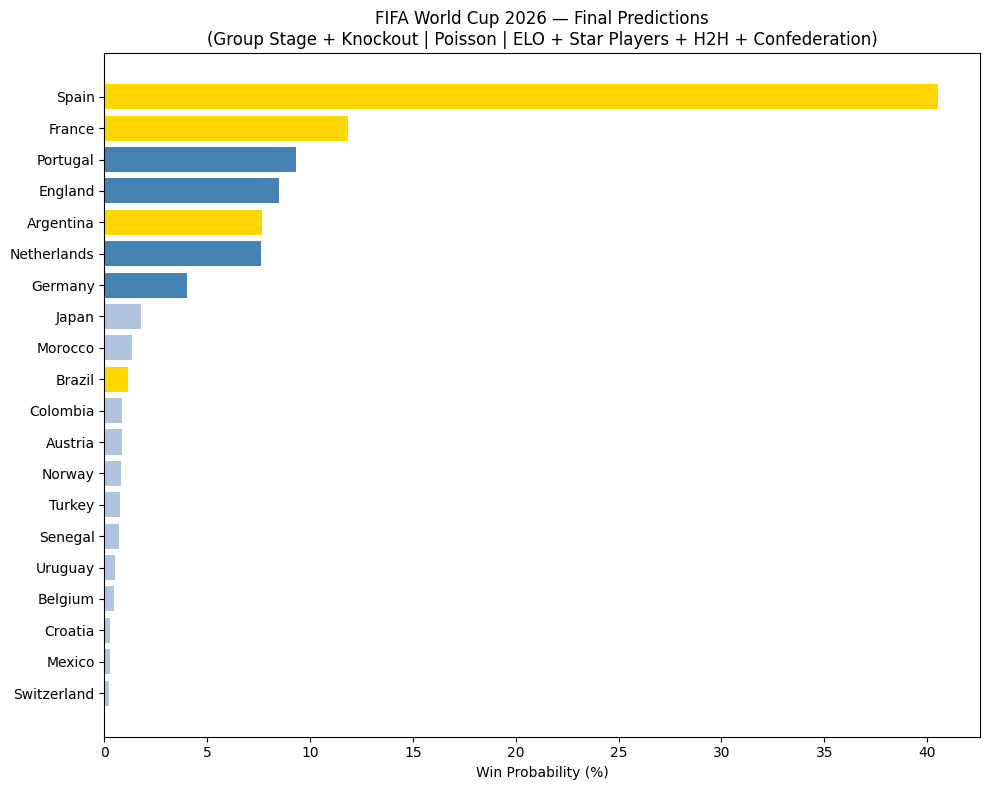

Final predictions saved!


In [24]:
top20 = results_df.head(20).sort_values('Win Probability (%)', ascending=True)

colors = []
for team in top20['Team']:
    if team in ['France', 'Argentina', 'Brazil', 'Spain']:
        colors.append('gold')
    elif team in ['England', 'Germany', 'Portugal', 'Netherlands']:
        colors.append('steelblue')
    else:
        colors.append('lightsteelblue')

plt.figure(figsize=(10, 8))
bars = plt.barh(top20['Team'], top20['Win Probability (%)'], color=colors)
plt.xlabel('Win Probability (%)')
plt.title('FIFA World Cup 2026 — Final Predictions\n(Group Stage + Knockout | Poisson | ELO + Star Players + H2H + Confederation)')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'Monte_Carlo_Simulation', 'wc2026_final_predictions.png'))
plt.show()

results_df.to_csv(os.path.join(BASE, 'Monte_Carlo_Simulation', 'predictions_final.csv'), index=False)
print("Final predictions saved!")

{'A': ['Mexico', 'South Korea', 'South Africa', 'Czech Republic'], 'B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'], 'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'], 'D': ['United States', 'Paraguay', 'Australia', 'Turkey'], 'E': ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador'], 'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'], 'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'], 'H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'], 'I': ['France', 'Senegal', 'Iraq', 'Norway'], 'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'], 'K': ['Portugal', 'DR Congo', 'Colombia', 'Uzbekistan'], 'L': ['England', 'Croatia', 'Ghana', 'Panama']}
